In [2]:
import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, Subset
from torchvision import transforms
from sklearn.metrics import f1_score
from PIL import Image
import os

# Pour la reproductibilité, parce qu'on est des gens sérieux
torch.manual_seed(42)
np.random.seed(42)

## Analyse des images fournies

In [3]:
def show_first_images_folder(folder, n=5, title="Folder dataset"):
    files = [f for f in os.listdir(folder) if f.lower().endswith(('.png', '.jpg', '.jpeg'))]

    plt.figure(figsize=(12, 3))

    for i, f in enumerate(files[:n]):
        path = os.path.join(folder, f)
        img = Image.open(path)

        plt.subplot(1, n, i+1)
        plt.imshow(img)
        plt.title(f)
        plt.axis("off")

    plt.suptitle(title)
    plt.show()

In [4]:
# Afficher la résolution des n premières images
def print_resolutions_folder(folder, n=5):
    files = [f for f in os.listdir(folder) if f.lower().endswith(('.png','.jpg','.jpeg'))]

    for f in files[:n]:
        img = Image.open(os.path.join(folder, f))
        print(f"{f} -> {img.size} (W x H)")

In [5]:
# Analyser les couleurs des n premières images
def analyze_colors_folder(folder, n=5):
    files = [f for f in os.listdir(folder) if f.endswith(('.png','.jpg','.jpeg'))]

    for f in files[:n]:
        img = Image.open(os.path.join(folder, f))

        img_np = np.array(img)

        print(f"\n{f}")
        print("shape:", img_np.shape)

        if len(img_np.shape) == 2:
            print("→ grayscale")
        elif img_np.shape[2] == 3:
            print("→ RGB")
        elif img_np.shape[2] == 4:
            print("→ RGBA")

In [6]:
# Analyser la structure du dataset
def explore_folder_structure(path):
    for root, dirs, files in os.walk(path):
        level = root.replace(path, "").count(os.sep)
        indent = "  " * level
        print(f"{indent}{os.path.basename(root)}/")
        subindent = "  " * (level + 1)
        for f in files[:5]:
            print(f"{subindent}{f}")

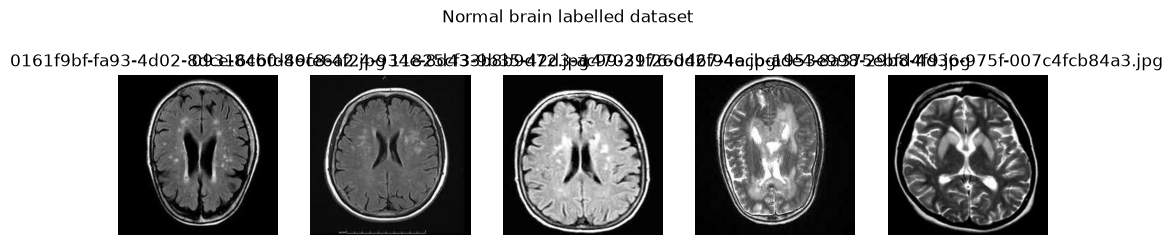

0161f9bf-fa93-4d02-8dce-84bfd49fe6a2.jpg -> (512, 512) (W x H)
09316c60-86c8-4f24-934e-8d433b8b9d72.jpg -> (512, 512) (W x H)
11825cf3-9b35-42d3-ac99-21f26dd2f94e.jpg -> (512, 512) (W x H)
14703976-0467-4acb-ade4-8a375ebfd4f9.jpg -> (512, 512) (W x H)
1953e998-29b8-4d36-975f-007c4fcb84a3.jpg -> (512, 512) (W x H)

0161f9bf-fa93-4d02-8dce-84bfd49fe6a2.jpg
shape: (512, 512, 3)
→ RGB

09316c60-86c8-4f24-934e-8d433b8b9d72.jpg
shape: (512, 512, 3)
→ RGB

11825cf3-9b35-42d3-ac99-21f26dd2f94e.jpg
shape: (512, 512, 3)
→ RGB

14703976-0467-4acb-ade4-8a375ebfd4f9.jpg
shape: (512, 512, 3)
→ RGB

1953e998-29b8-4d36-975f-007c4fcb84a3.jpg
shape: (512, 512, 3)
→ RGB


In [7]:
# Nom des datasets à charger
normal_brain_labelled_data_file = '/Users/emman/Formation/P7 SSL/mri_dataset_brain_cancer_oc/avec_labels/normal/top'

# Normal brain labelled dataset
show_first_images_folder(normal_brain_labelled_data_file, title='Normal brain labelled dataset')
print_resolutions_folder(normal_brain_labelled_data_file)
analyze_colors_folder(normal_brain_labelled_data_file)

In [8]:
# cancer brain labelled dataset
cancer_brain_labelled_data_file = '/Users/emman/Formation/P7 SSL/mri_dataset_brain_cancer_oc/avec_labels/cancer'

show_first_images_folder(cancer_brain_labelled_data_file, title='Cancer brain labelled dataset')
print_resolutions_folder(cancer_brain_labelled_data_file)
analyze_colors_folder(cancer_brain_labelled_data_file)

<Figure size 1200x300 with 0 Axes>

In [9]:
# Unlabelled dataset
unlabelled_data_file = '/Users/emman/Formation/P7 SSL/mri_dataset_brain_cancer_oc/sans_label'

show_first_images_folder(unlabelled_data_file, title='Unlabelled dataset')
print_resolutions_folder(unlabelled_data_file)
analyze_colors_folder(unlabelled_data_file)

<Figure size 1200x300 with 0 Axes>

In [10]:
# Lit l'ensemble des images du répertoire passé en paramètre et de ses sous-répertoires
from pathlib import Path
import pandas as pd

def build_dataframe(root):
    root = Path(root)

    rows = []

    for label_dir in ["normal", "cancer"]:
        label_path = root / label_dir

        if not label_path.exists():
            continue

        for view_path in label_path.iterdir():

            if not view_path.is_dir():
                continue

            view = view_path.name

            for img_path in view_path.glob("*"):

                if img_path.suffix.lower() not in [
                    ".png",
                    ".jpg",
                    ".jpeg",
                    ".bmp",
                    ".tif",
                    ".tiff"
                ]:
                    continue

                rows.append({
                    "filepath": str(img_path),
                    "filename": img_path.name,
                    "label": label_dir,
                    "view": view
                })

    return pd.DataFrame(rows)



label       cancer  normal
view                      
back            15       1
left_side        6       1
right_side       7       0
top             22      48
label         cancer    normal
view                          
back        0.937500  0.062500
left_side   0.857143  0.142857
right_side  1.000000  0.000000
top         0.314286  0.685714


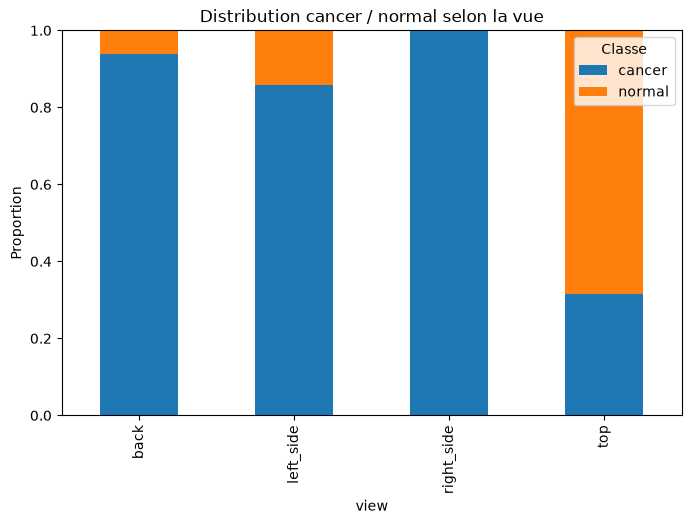

Chi2 : 32.479
p-value : 0.00000


In [11]:
# Analyse => le modèle risque d'associer les autres vues que 'top' a des cancers. On met les autres vues de côté pour le moment.

# Récupération des images labellisées
df = build_dataframe("/Users/emman/Formation/P7 SSL/mri_dataset_brain_cancer_oc/avec_labels/")
df.head()

# Analyse en nombre
ct = pd.crosstab(df["view"], df["label"])
print(ct)

# Analyse en pourcentage
ct_pct = pd.crosstab(
    df["view"],
    df["label"],
    normalize="index"
)
print(ct_pct)

# Visualisation
ct_pct.plot(
    kind="bar",
    stacked=True,
    figsize=(8, 5)
)

plt.ylabel("Proportion")
plt.title("Distribution cancer / normal selon la vue")
plt.legend(title="Classe")
plt.show()

# Test statistique
from scipy.stats import chi2_contingency

chi2, p_value, _, expected = chi2_contingency(ct)

print(f"Chi2 : {chi2:.3f}")
print(f"p-value : {p_value:.5f}")

## Calcul des embeddings et de la couche ResNet optimale

In [12]:
# Génération des embeddings

from pathlib import Path
import numpy as np
import pandas as pd
from PIL import Image

import torch
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
from torchvision.models import resnet50, ResNet50_Weights

In [13]:
# Fonction de chargement des images
class BrainTopDataset(Dataset):

    def __init__(self, root_dir, transform=None):
        self.samples = []
        self.transform = transform

        for label_name, label in {
            "normal": 0,
            "cancer": 1
        }.items():

            folder = root_dir / label_name / "top"

            for img_path in folder.glob("*"):

                if img_path.suffix.lower() not in [
                    ".png",
                    ".jpg",
                    ".jpeg",
                    ".bmp",
                    ".tif",
                    ".tiff"
                ]:
                    continue

                self.samples.append(
                    (
                        str(img_path),
                        label
                    )
                )

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):

        path, label = self.samples[idx]

        img = Image.open(path).convert("L")

        if self.transform:
            img = self.transform(img)

        return img, label, path


In [14]:
DATA_DIR = Path("/Users/emman/Formation/P7 SSL/mri_dataset_brain_cancer_oc/avec_labels/")

# Pré-traitement
transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.Grayscale(num_output_channels=3),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

# Chargement du dataset
dataset = BrainTopDataset(
    DATA_DIR,
    transform=transform
)

print(len(dataset))

loader = DataLoader(
    dataset,
    batch_size=16,
    shuffle=False
)

70


In [15]:
# Chargement de ResNet50 et utilisation en extracteur uniquement
weights = ResNet50_Weights.DEFAULT

model = resnet50(weights=weights)
model.eval()

encoder2 = torch.nn.Sequential(
    model.conv1,
    model.bn1,
    model.relu,
    model.maxpool,
    model.layer1,
    model.layer2,
    torch.nn.AdaptiveAvgPool2d((1, 1))
)

encoder3 = torch.nn.Sequential(
    model.conv1,
    model.bn1,
    model.relu,
    model.maxpool,
    model.layer1,
    model.layer2,
    model.layer3,
    torch.nn.AdaptiveAvgPool2d((1, 1))
)

encoder4 = torch.nn.Sequential(
    *list(model.children())[:-1]
)

# Extraction des embeddings
device = (
    "cuda"
    if torch.cuda.is_available()
    else "cpu"
)

def extract_embeddings(encoder, loader):
    encoder = encoder.to(device)
    encoder.eval()

    embeddings = []
    labels = []

    with torch.no_grad():
        for imgs, y, _ in loader:

            imgs = imgs.to(device)

            emb = encoder(imgs)

            emb = emb.squeeze(-1).squeeze(-1)

            embeddings.append(
                emb.cpu().numpy()
            )

            labels.extend(
                y.numpy()
            )

    embeddings = np.concatenate(
        embeddings,
        axis=0
    )

    labels = np.array(labels)

    return embeddings, labels


In [16]:
# Calculs des embeddings
X2, y = extract_embeddings(
    encoder2,
    loader
)

X3, y = extract_embeddings(
    encoder3,
    loader
)

X4, y = extract_embeddings(
    encoder4,
    loader
)

print(X2.shape)
print(X3.shape)
print(X4.shape)

(70, 512)
(70, 1024)
(70, 2048)


In [ ]:
# Evaluation de la perf d'un modèle de régression logistique en fonction du nombre de couches du cnn utilisées pour les embeddings
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import StratifiedKFold
from sklearn.model_selection import cross_val_score

# Régression logistique pour calcul du F1 score
def evaluate_embeddings(X, y):

    clf = Pipeline([
        ("scaler", StandardScaler()),
        ("model", LogisticRegression(
            max_iter=5000,
            class_weight="balanced" # balance le déséquilibre des classes
        ))
    ])

    cv = StratifiedKFold(
        n_splits=5,
        shuffle=True,
        random_state=42
    )

    scores = cross_val_score(
        clf,
        X,
        y,
        cv=cv,
        scoring="f1"
    )

    return scores

# Evaluation des 3 couches
scores2 = evaluate_embeddings(X2, y)
scores3 = evaluate_embeddings(X3, y)
scores4 = evaluate_embeddings(X4, y)

results = pd.DataFrame({
    "layer": ["layer2", "layer3", "layer4"],
    "mean_f1": [
        scores2.mean(),
        scores3.mean(),
        scores4.mean()
    ],
    "std_f1": [
        scores2.std(),
        scores3.std(),
        scores4.std()
    ]
})

results.sort_values(
    "mean_f1",
    ascending=False
)

,layer,mean_f1,std_f1
1,layer3,0.937778,0.081225
0,layer2,0.937374,0.051663
2,layer4,0.835873,0.131029


# Réduction de dimension

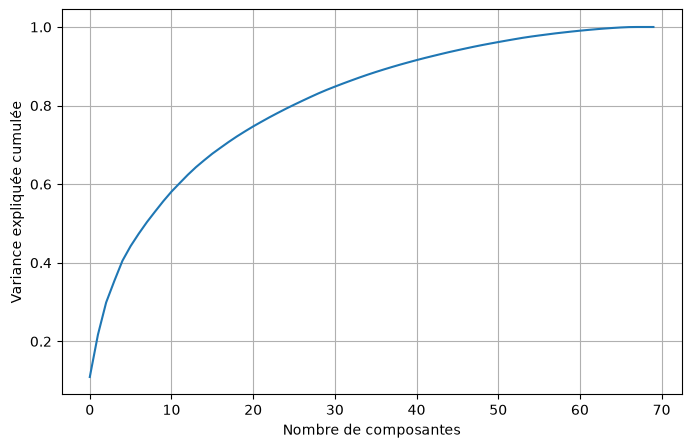

In [ ]:
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

# standardisation scaler
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X3)


# Analyse ACP
pca = PCA()
X_pca = pca.fit_transform(X_scaled)

# Variance cumulée
cum_var = np.cumsum(
    pca.explained_variance_ratio_
)

plt.figure(figsize=(8,5))
plt.plot(cum_var)
plt.xlabel("Nombre de composantes")
plt.ylabel("Variance expliquée cumulée")
plt.grid()
plt.show()

In [ ]:
# Recherche des features en fonction du seuil de variance optimum défini à 0.95
n_components = np.argmax(
    cum_var >= 0.95
) + 1

print(n_components)

49


In [20]:
pca = PCA(
    n_components=n_components,
    random_state=42
)

X_pca = pca.fit_transform(
    X_scaled
)

scores_pca = evaluate_embeddings(
    X_pca,
    y
)

print(
    scores_pca.mean(),
    scores_pca.std()
)

0.5276190476190477 0.13756548636394506


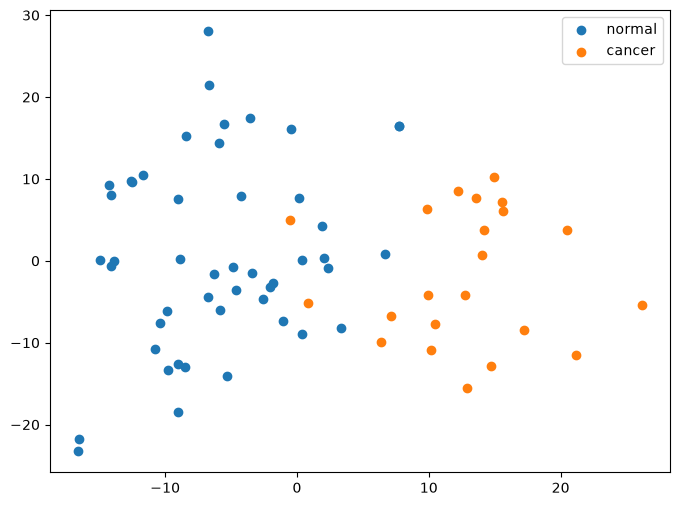

In [ ]:
# Visualisation 2D => les catégories sont bien séparées
pca2 = PCA(
    n_components=2,
    random_state=42
)

X_vis = pca2.fit_transform(
    X_scaled
)

plt.figure(figsize=(8,6))

plt.scatter(
    X_vis[y==0,0],
    X_vis[y==0,1],
    label="normal"
)

plt.scatter(
    X_vis[y==1,0],
    X_vis[y==1,1],
    label="cancer"
)

plt.legend()
plt.show()

# Classification d'un petit jeu trié sur la vue

In [22]:
# Classifier sur 108 images non labellisées mais dont la vue est triée
from pathlib import Path

rows = []

root = Path("/Users/emman/Formation/P7 SSL/mri_dataset_brain_cancer_oc/sans_label/")

for p in (root / "top").glob("*"):
    rows.append(
        {
            "filepath": str(p),
            "is_top": 1
        }
    )

for folder in ["back", "left_side", "right_side"]:

    for p in (root / folder).glob("*"):
        rows.append(
            {
                "filepath": str(p),
                "is_top": 0
            }
        )

df_views = pd.DataFrame(rows)

print(df_views["is_top"].value_counts())

is_top
1    58
0    50
Name: count, dtype: int64


In [23]:
from torch.utils.data import Dataset
from PIL import Image

class ViewDataset(Dataset):

    def __init__(self, df, transform):

        self.df = df.reset_index(drop=True)
        self.transform = transform

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):

        row = self.df.iloc[idx]

        img = Image.open(
            row["filepath"]
        ).convert("L")

        img = self.transform(img)

        return (
            img,
            row["is_top"]
        )

In [24]:
# Calcul des embeddings
def extract_embeddings_views(
    encoder,
    loader
):

    encoder.eval()
    encoder.to(device)

    embeddings = []
    labels = []

    with torch.no_grad():

        for imgs, y in loader:

            imgs = imgs.to(device)

            emb = encoder(imgs)

            emb = emb.squeeze(-1)
            emb = emb.squeeze(-1)

            embeddings.append(
                emb.cpu().numpy()
            )

            labels.extend(
                y.numpy()
            )

    X = np.concatenate(
        embeddings,
        axis=0
    )

    y = np.array(labels)

    return X, y

In [25]:
dataset_views = ViewDataset(
    df_views,
    transform
)

loader_views = DataLoader(
    dataset_views,
    batch_size=32,
    shuffle=False
)
X_view, y_view = extract_embeddings_views(
    encoder3,
    loader_views
)

print(X_view.shape)

(108, 1024)


In [26]:
# Normalisation et réduction de dimension
X_view_scaled = scaler.transform(
    X_view
)

X_view_pca = pca.transform(
    X_view_scaled
)

In [27]:
# Evaluer le classifieur
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import (
    StratifiedKFold,
    cross_val_score
)

clf_view = LogisticRegression(
    class_weight="balanced",
    max_iter=5000
)

cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

scores = cross_val_score(
    clf_view,
    X_view_pca,
    y_view,
    cv=cv,
    scoring="f1"
)

print(scores)
print(scores.mean())

[1.         1.         1.         0.95238095 0.95652174]
0.9817805383022774


In [28]:
clf_view.fit(
    X_view_pca,
    y_view
)

,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",'balanced'
,"max_iter max_iter: int, default=100Maximum number of iterations taken for the solvers to converge.",5000
,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add an L2 penalty term and it is the default choice;- `'l1'`: add an L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` and `C` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'`, `l1_ratio` set to any float between 0 and 1 for `penalty='elasticnet'`, and `C=np.inf` for `penalty=None`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation <regularized-logistic-loss>`) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary <random_state>` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Defaul

# Classification du jeu principal par vue (top / non top)

In [29]:
from pathlib import Path
from torch.utils.data import Dataset
from PIL import Image

class UnlabeledDataset(Dataset):

    def __init__(self, root_dir, transform=None):

        self.transform = transform
        self.samples = []

        root = Path(root_dir)

        for ext in [
            "*.png",
            "*.jpg",
            "*.jpeg",
            "*.bmp",
            "*.tif",
            "*.tiff"
        ]:
            self.samples.extend(
                root.rglob(ext)
            )

        self.samples = sorted(self.samples)

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):

        path = self.samples[idx]

        img = Image.open(path).convert("L")

        if self.transform:
            img = self.transform(img)

        return img, str(path)

In [30]:
unl_dataset = UnlabeledDataset(
    "/Users/emman/Formation/P7 SSL/mri_dataset_brain_cancer_oc/sans_label/Unsorted",
    transform=transform
)

print(len(unl_dataset))

1298


In [31]:
from torch.utils.data import DataLoader

unl_loader = DataLoader(
    unl_dataset,
    batch_size=32,
    shuffle=False,
    num_workers=0
)

In [32]:
# Embeddings sur la couche 3
device = (
    "cuda"
    if torch.cuda.is_available()
    else "cpu"
)

encoder3.to(device)
encoder3.eval()

Sequential(
  (0): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
  (2): ReLU(inplace=True)
  (3): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (4): Sequential(
    (0): Bottleneck(
      (conv1): Conv2d(64, 64, kernel_size=(1, 1), stride=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
      (conv3): Conv2d(64, 256, kernel_size=(1, 1), stride=(1, 1), bias=False)
      (bn3): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (downsample): Sequential(
        (0): Conv2d(64, 256, ker

In [33]:

embeddings = []
paths = []

with torch.no_grad():

    for imgs, batch_paths in unl_loader:

        imgs = imgs.to(device)

        emb = encoder3(imgs)

        emb = emb.squeeze(-1).squeeze(-1)

        embeddings.append(
            emb.cpu().numpy()
        )

        paths.extend(
            batch_paths
        )

In [34]:
X_unl = np.concatenate(
    embeddings,
    axis=0
)

print(X_unl.shape)

(1298, 1024)


In [35]:
# Scalerisation et PCA
X_unl_scaled = scaler.transform(
    X_unl
)
X_unl_pca = pca.transform(
    X_unl_scaled
)

print(X_unl_pca.shape)


(1298, 49)


In [36]:
# Entrainement avec le modèle de reg log précédent
proba_top = clf_view.predict_proba(
    X_unl_pca
)[:, 1]

df_unl = pd.DataFrame({
    "filepath": paths,
    "proba_top": proba_top
})

df_unl.head()

,filepath,proba_top
0,\Users\emman\Formation\P7 SSL\mri_dataset_brai...,0.999331
1,\Users\emman\Formation\P7 SSL\mri_dataset_brai...,0.993879
2,\Users\emman\Formation\P7 SSL\mri_dataset_brai...,0.999838
3,\Users\emman\Formation\P7 SSL\mri_dataset_brai...,0.010336
4,\Users\emman\Formation\P7 SSL\mri_dataset_brai...,0.000003


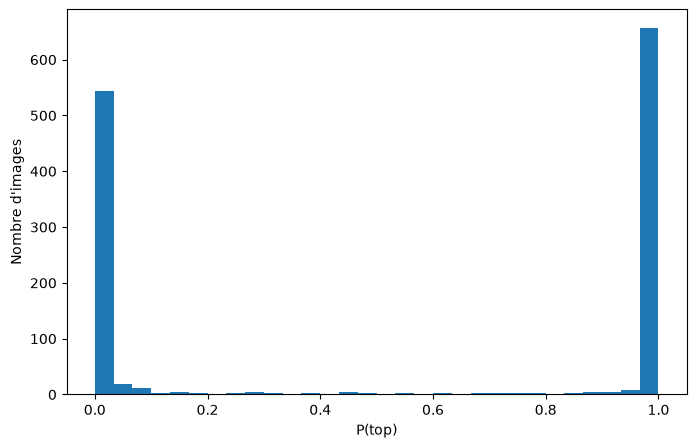

In [37]:
# Visualisation distribution des vues
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))
plt.hist(
    proba_top,
    bins=30
)
plt.xlabel("P(top)")
plt.ylabel("Nombre d'images")
plt.show()

In [38]:
# Tri des vues
threshold = 0.95

mask_top = (
    proba_top > threshold
)

df_top = df_unl.loc[
    mask_top
].copy()

print(
    f"{len(df_top)} images top retenues"
)

X_unl_top = X_unl_pca[
    mask_top
]

663 images top retenues


# Classification du jeu 'top' par valeur 'normal' ou 'cancer'

In [40]:
X_all = np.vstack([
    X_pca,
    X_unl_top
])

print(X_all.shape)

(733, 49)


In [ ]:
# Projection UMAP des données
from umap import UMAP

umap = UMAP(
    n_neighbors=15,
    min_dist=0.1,
    n_components=2,
    metric="euclidean",
    random_state=42
)

X_umap = umap.fit_transform(X_all)

print(X_umap.shape)

c:\Users\emman\Formation\P7 SSL\.venv\Lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


(733, 2)


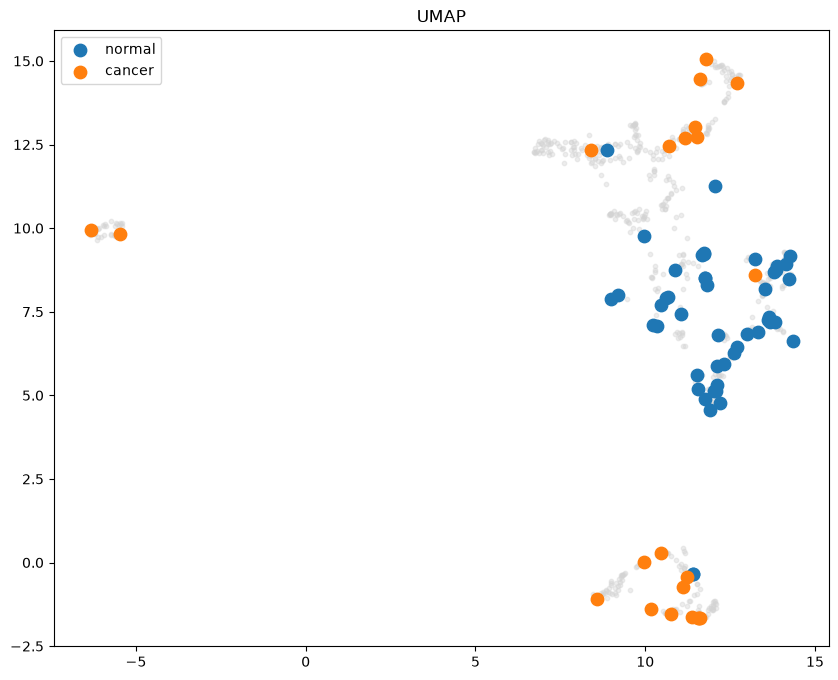

In [44]:
# Représentation graphique
n_lab = len(X_pca)

X_lab_umap = X_umap[:n_lab]
X_unl_umap = X_umap[n_lab:]

plt.figure(figsize=(10,8))

# non labellisées
plt.scatter(
    X_unl_umap[:,0],
    X_unl_umap[:,1],
    c="lightgray",
    s=10,
    alpha=0.4
)

# normales
plt.scatter(
    X_lab_umap[y==0,0],
    X_lab_umap[y==0,1],
    label="normal",
    s=80
)

# cancers
plt.scatter(
    X_lab_umap[y==1,0],
    X_lab_umap[y==1,1],
    label="cancer",
    s=80
)

plt.legend()
plt.title("UMAP")
plt.show()

In [49]:
# Classification DBSCAN
import hdbscan

clusterer = hdbscan.HDBSCAN(
    min_cluster_size=20
)

clusters = clusterer.fit_predict(
    X_umap
)

# Analyse des clusters
np.unique(clusters)

n_clusters = len(set(clusters)) - (1 if -1 in clusters else 0)

print("Nombre de clusters :", n_clusters)

Nombre de clusters : 3


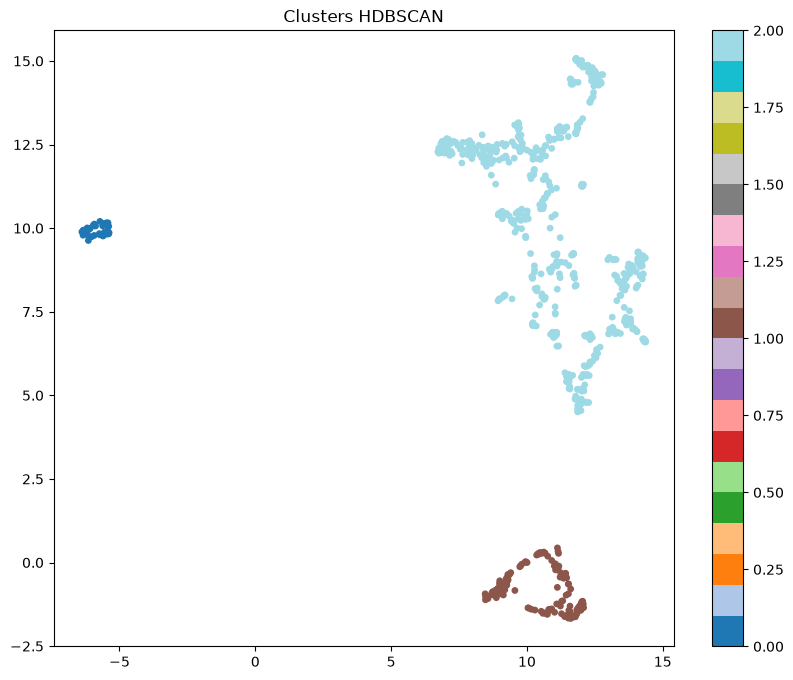

In [52]:
plt.figure(figsize=(10,8))

plt.scatter(
    X_umap[:,0],
    X_umap[:,1],
    c=clusters,
    cmap="tab20",
    s=15
)

plt.title("Clusters HDBSCAN")
plt.colorbar()
plt.show()

In [51]:
# Calcul du score ARI sur les données fortement labellisées
from sklearn.metrics import adjusted_rand_score

clusters_lab = clusters[:n_lab]

# retrait du bruit
mask = clusters_lab != -1


ari = adjusted_rand_score(
    y[mask],
    clusters_lab[mask]
)

print("ARI :", ari)

ARI : 0.4263704941396172


# Clustering avec KMeans

In [53]:
# Concaténation des fichiers d'images en vue top
X_all = np.vstack([
    X_pca,
    X_unl_top
])

print(X_all.shape)

(733, 49)


In [ ]:
# Clustering avec KMeans

from sklearn.cluster import KMeans

kmeans = KMeans(
    n_clusters=2,
    random_state=42,
    n_init=20
)

clusters = kmeans.fit_predict(X_all)

n_lab = len(X_pca)

clusters_lab = clusters[:n_lab]
clusters_unl = clusters[n_lab:]

In [56]:
# Score ARI

from sklearn.metrics import adjusted_rand_score

ari = adjusted_rand_score(
    y,
    clusters_lab
)

print(f"ARI : {ari:.3f}")

ARI : 0.722


In [57]:
# Composition des clusters

pd.crosstab(
    clusters_lab,
    y,
    rownames=["cluster"],
    colnames=["label"]
)

label,0,1
cluster,,
0,0,17
1,48,5


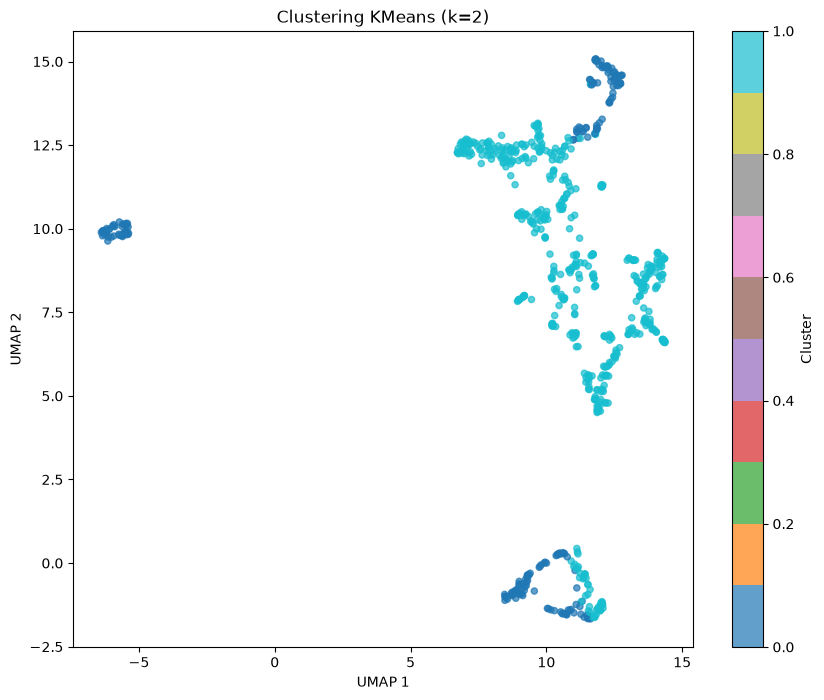

In [76]:
plt.figure(figsize=(10, 8))

plt.scatter(
    X_umap[:, 0],
    X_umap[:, 1],
    c=clusters,
    cmap="tab10",
    s=20,
    alpha=0.7
)

plt.title("Clustering KMeans (k=2)")
plt.xlabel("UMAP 1")
plt.ylabel("UMAP 2")
plt.colorbar(label="Cluster")
plt.show()

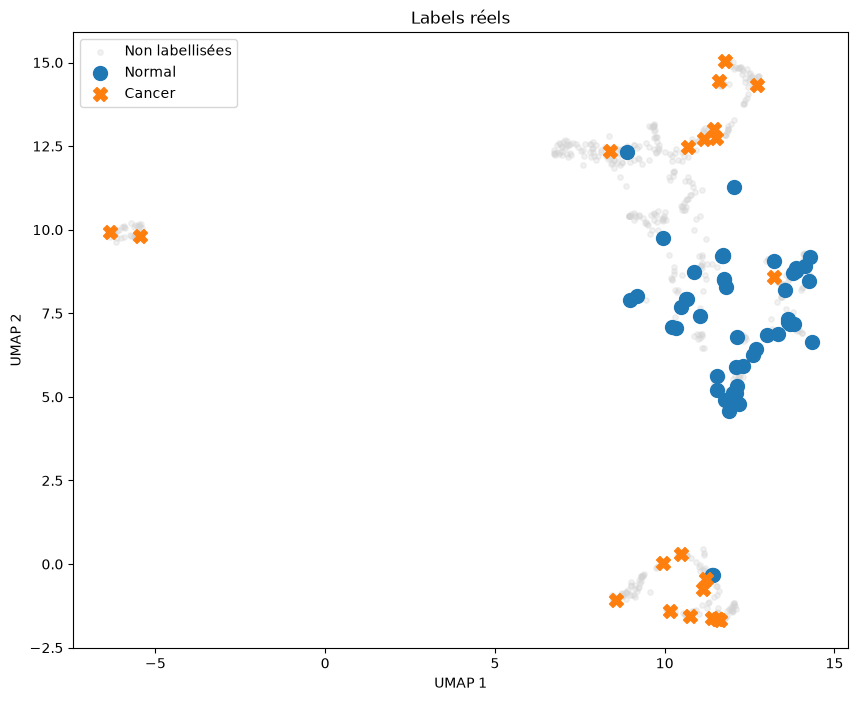

In [77]:
X_lab_umap = X_umap[:n_lab]
X_unl_umap = X_umap[n_lab:]

plt.figure(figsize=(10, 8))

# non labellisées
plt.scatter(
    X_unl_umap[:, 0],
    X_unl_umap[:, 1],
    c="lightgray",
    s=15,
    alpha=0.3,
    label="Non labellisées"
)

# normales
plt.scatter(
    X_lab_umap[y == 0, 0],
    X_lab_umap[y == 0, 1],
    s=100,
    marker="o",
    label="Normal"
)

# cancers
plt.scatter(
    X_lab_umap[y == 1, 0],
    X_lab_umap[y == 1, 1],
    s=100,
    marker="X",
    label="Cancer"
)

plt.legend()
plt.title("Labels réels")
plt.xlabel("UMAP 1")
plt.ylabel("UMAP 2")
plt.show()

In [58]:
# Attribution des clusters aux labels
mapping = {}

for c in np.unique(clusters_lab):

    mask = clusters_lab == c

    majority_label = np.bincount(
        y[mask]
    ).argmax()

    mapping[c] = majority_label

print(mapping)

{np.int32(0): np.int64(1), np.int32(1): np.int64(0)}


In [ ]:
# Création des labels faibles
weak_labels = np.array([
    mapping[c]
    for c in clusters_unl
])

np.bincount(weak_labels)

array([476, 187])

In [78]:
# Création du df avec les labels
distances = kmeans.transform(X_all)

dist_unl = distances[70:]

assigned_dist = dist_unl[
    np.arange(len(clusters_unl)),
    clusters_unl
]

df_weak = pd.DataFrame({
    "filepath": df_top["filepath"].values,
    "cluster": clusters_unl,
    "weak_label": weak_labels,
    "distance": assigned_dist
})

df_weak.to_csv(
    "artifacts/weak_labels.csv",
    index=False
)

df_weak["weak_label"].value_counts()

weak_label
0    476
1    187
Name: count, dtype: int64